## Name: Aryan Mahesh Patil   
### RollNo: 51
#### Exp: 6              Date: 23|02|2026

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score, recall_score, f1_score

In [60]:
data=pd.read_csv("credit.csv", skiprows=1)
data=data.sample(1000, random_state=42)

print(data.columns)

data.drop(columns=['ID'], inplace=True)
print(data.columns)

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [61]:
data.isnull().sum()

LIMIT_BAL                     0
GENDER                        0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [62]:
print(data.head(10))

       LIMIT_BAL  GENDER  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
2308       30000       1          2         2   25      0      0      0   
22404     150000       2          1         2   26      0      0      0   
23397      70000       2          3         1   32      0      0      0   
25058     130000       1          3         2   49      0      0      0   
2664       50000       2          2         2   36      0      0      0   
8511       50000       2          2         2   29     -1     -1     -1   
5148      110000       1          3         2   33      1      2      0   
7790      140000       2          1         1   32      1     -2     -2   
11311     260000       2          2         3   38     -1     -1     -1   
19043      80000       2          2         2   23      0      0     -2   

       PAY_4  PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
2308       0      0  ...      12580      13716      14828      1500      2000   
22404      0

In [63]:
print(data.info)

<bound method DataFrame.info of        LIMIT_BAL  GENDER  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
2308       30000       1          2         2   25      0      0      0   
22404     150000       2          1         2   26      0      0      0   
23397      70000       2          3         1   32      0      0      0   
25058     130000       1          3         2   49      0      0      0   
2664       50000       2          2         2   36      0      0      0   
...          ...     ...        ...       ...  ...    ...    ...    ...   
1668      100000       1          2         2   30     -2     -2     -2   
24758     100000       1          3         1   40      2      0      0   
4336      330000       2          2         1   39      8      7      6   
15543     180000       1          1         2   30      1     -2     -2   
24409      50000       1          1         1   37      0      0      0   

       PAY_4  PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1

In [64]:
y=data['default payment next month']
x=data[['BILL_AMT1','BILL_AMT2']]

print(x.dtypes)
print(x.head())

BILL_AMT1    int64
BILL_AMT2    int64
dtype: object
       BILL_AMT1  BILL_AMT2
2308        8864      10062
22404     136736     125651
23397      70122      69080
25058      20678      18956
2664       94228      47635


In [65]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.3, random_state=42)

In [66]:
scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [67]:
models={
    "Linear SVM":SVC(kernel='linear', C=1, class_weight='balanced'),
    "Ploynomial SVM": SVC(kernel='poly',
                          degree=2,
                          C=1,
                          gamma='scale',
                          class_weight='balanced'),
    "RBF SVM": SVC(kernel='rbf',
                   C=5,
                   gamma=0.1,
                   class_weight='balanced')
}

In [68]:
for name,model in models.items():
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    y_pred_train=model.predict(x_train)
    print("\n", name)
    print("Train Accuracy:\n",accuracy_score(y_train, y_pred_train))
    print("Test Accuracy:\n",accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred,zero_division=0))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))


 Linear SVM
Train Accuracy:
 0.6914285714285714
Test Accuracy:
 0.66
Confusion Matrix:
 [[184  36]
 [ 66  14]]
Precision: 0.28
Recall: 0.175
F1 Score: 0.2153846153846154

 Ploynomial SVM
Train Accuracy:
 0.7714285714285715
Test Accuracy:
 0.7333333333333333
Confusion Matrix:
 [[217   3]
 [ 77   3]]
Precision: 0.5
Recall: 0.0375
F1 Score: 0.06976744186046512

 RBF SVM
Train Accuracy:
 0.35428571428571426
Test Accuracy:
 0.3566666666666667
Confusion Matrix:
 [[ 41 179]
 [ 14  66]]
Precision: 0.2693877551020408
Recall: 0.825
F1 Score: 0.40615384615384614


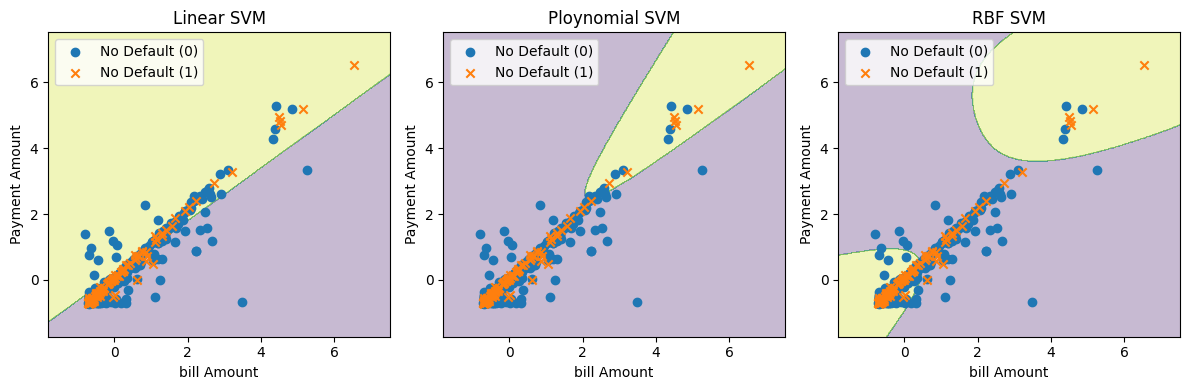

In [76]:
def plot_boundary(model,title):
    h=0.02
    x_min, x_max = x_train[:,0].min()-1,x_train[:,0].max()+1
    y_min, y_max = x_train[:,1].min()-1,x_train[:,1].max()+1

    xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
    )

    z=model.predict(np.c_[xx.ravel(), yy.ravel()])
    z=z.reshape(xx.shape)

    plt.contourf(xx, yy, z, alpha=0.3)
    plt.scatter(x_train[y_train==0, 0],
                x_train[y_train==0,1],
    label='No Default (0)',
    marker='o')

    plt.scatter(x_train[y_train==1, 0],
                x_train[y_train==1,1],
    label='No Default (1)',
    marker='x')

    plt.legend()
    plt.title(title)
    plt.xlabel("bill Amount")
    plt.ylabel("Payment Amount")

plt.figure(figsize=(12,4))

for i, (name,model) in enumerate(models.items()):
    plt.subplot(1,3, i+1)
    model.fit(x_train, y_train)
    plot_boundary(model, name)

plt.tight_layout()
plt.show()